# V3 empirical study — 1.5-year fixed calibration — return-based models

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | GBM, Modified GBM, GARCH, Merton, GARCH–Merton |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **none** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At the first session t0 of each 1-year evaluation window, parameters use only returns and listed quotes with `trading_date ≤ t0`. Those parameters are held for every Monday contract in the window. LSM prices each contract with that single calibration row. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all five models in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
This notebook is a grouped companion. It loads stored cells and does **not** re-run LSM. To rebuild only this group's PDF/notebook, call `groups.write_group(...)`. Do not set RECOMPUTE on the six-model engine; that would overwrite the original study files.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V4-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
print('cells', len(payload['cells']), 'models', payload['meta']['models'])
# Rebuild this group's PDF/notebook only (does not overwrite the six-model study):
# groups.write_group('return_based')

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = GARCH–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,39.85,1.5118,-1.3570,-29.27,25.5%,3
Modified GBM,43.13,1.6255,-1.5635,-35.30,26.1%,5
GARCH,36.15,1.3736,-0.9849,-18.26,23.5%,2
Merton,40.12,1.5229,-1.3790,-29.99,24.9%,4
GARCH–Merton,35.69,1.3398,-0.8186,-13.54,20.8%,1


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,40.10,0.7145,+0.5358,+27.51,26.2%,2
Modified GBM,41.67,0.7464,+0.5698,+29.03,26.1%,4
GARCH,38.23,0.6786,+0.4831,+25.30,24.6%,1
Merton,40.53,0.7231,+0.5464,+27.95,24.2%,3
GARCH–Merton,45.88,0.8274,+0.6986,+34.18,22.4%,5


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,23.62,0.8840,-0.1277,+1.81,20.8%,4
Modified GBM,23.03,0.8902,-0.2283,-0.59,22.2%,3
GARCH,25.60,1.0389,-0.8655,-16.06,18.9%,5
Merton,22.81,0.9091,-0.4865,-6.72,17.7%,1
GARCH–Merton,22.86,0.9032,-0.4350,-5.93,16.7%,2


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,57.52,2.9208,-0.5111,+18.64,24.3%,2
Modified GBM,59.99,2.9847,-0.3345,+21.88,23.9%,3
GARCH,60.68,2.9733,-0.3077,+22.51,22.9%,4
Merton,56.81,2.9399,-0.5830,+17.28,20.3%,1
GARCH–Merton,70.25,3.1595,+0.2869,+33.51,20.3%,5


## 2.2 Detailed tables — Company summary


Same four-regime layout as SPY. Each value is the arithmetic mean of **AAPL, MSFT, AMZN**. Ranking uses mean RMSE%.


### Table Co-1. Company summary · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2008-2009', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,32.08,1.0927,-0.1692,-4.59,23.9%,4
Modified GBM,30.51,1.0614,-0.4437,-9.68,25.3%,2
GARCH,31.21,1.0899,-0.0949,+2.20,22.4%,3
Merton,30.09,1.0744,-0.2531,-4.56,18.7%,1
GARCH–Merton,43.19,1.3542,+0.6781,+21.13,17.4%,5


### Table Co-2. Company summary · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = GARCH** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2013-2014', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,47.76,2.2220,+1.4315,+36.60,24.6%,4
Modified GBM,44.74,2.0480,+1.2472,+33.61,25.7%,2
GARCH,42.14,1.7764,+0.9287,+30.56,23.3%,1
Merton,45.10,2.2098,+1.3747,+33.84,18.7%,3
GARCH–Merton,66.53,2.7630,+2.5061,+57.71,17.5%,5


### Table Co-3. Company summary · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · mean of AAPL, MSFT, AMZN · n̄ = 51 · **BEST = Modified GBM** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2018-2019', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,20.48,4.6263,-2.0225,-2.87,23.3%,3
Modified GBM,20.18,4.6410,-1.3699,-3.86,23.8%,1
GARCH,20.19,4.6326,-2.0914,-5.32,21.8%,2
Merton,22.32,4.7292,-2.3122,+2.55,13.8%,4
GARCH–Merton,23.79,5.1311,+1.3847,+8.36,16.6%,5


### Table Co-4. Company summary · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = GARCH** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2019-2020', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,48.08,10.4481,+4.7656,+23.77,24.2%,2
Modified GBM,48.43,10.8481,+5.6520,+23.33,24.2%,3
GARCH,41.87,9.2660,-1.0332,+15.36,22.4%,1
Merton,49.62,10.6941,+5.4435,+25.70,19.8%,4
GARCH–Merton,55.47,10.1345,+2.6265,+32.21,19.4%,5


## 2.3 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,34.70,1.7325,-0.2012,+2.49,23.4%,3
Modified GBM,32.72,1.6706,-0.6554,-4.84,24.4%,1
GARCH,35.04,1.7531,-0.1784,+2.83,21.8%,4
Merton,34.57,1.7293,-0.2406,+1.71,21.0%,2
GARCH–Merton,43.53,2.0289,+0.7015,+16.92,16.7%,5


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,57.70,3.8194,+3.8194,+51.38,24.4%,4
Modified GBM,51.10,3.3484,+3.3484,+44.85,25.7%,2
GARCH,39.62,2.4884,+2.3946,+32.33,23.1%,1
Merton,57.50,3.8718,+3.8718,+51.52,19.1%,3
GARCH–Merton,67.13,4.6054,+4.6054,+61.25,17.2%,5


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,16.77,0.8809,-0.5584,-7.11,23.8%,1
Modified GBM,16.88,0.8919,-0.5478,-6.91,24.5%,2
GARCH,17.11,0.9076,-0.6227,-8.15,22.6%,3
Merton,18.08,0.8489,+0.2167,+5.33,14.1%,5
GARCH–Merton,17.34,0.8370,+0.0909,+3.31,19.3%,4


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,41.39,3.1111,+0.6446,+18.83,24.0%,1
Modified GBM,43.50,3.2399,+0.9173,+21.54,24.2%,2
GARCH,45.91,3.3764,+1.2410,+24.56,22.0%,4
Merton,43.70,3.2565,+0.9786,+22.02,17.8%,3
GARCH–Merton,68.46,5.0306,+3.8961,+50.08,18.7%,5


## 2.4 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,29.17,0.3120,-0.2729,-19.88,25.5%,4
Modified GBM,28.96,0.3119,-0.2681,-19.42,26.3%,3
GARCH,26.24,0.2848,-0.0629,+0.36,23.1%,2
Merton,26.16,0.2932,-0.1837,-11.78,18.4%,1
GARCH–Merton,32.88,0.2963,+0.0849,+14.04,20.0%,5


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,62.49,0.4284,+0.4262,+52.88,24.7%,3
Modified GBM,60.58,0.4138,+0.4100,+51.07,26.0%,2
GARCH,64.23,0.4441,+0.4431,+54.76,23.9%,4
Merton,55.50,0.3746,+0.3666,+45.96,17.5%,1
GARCH–Merton,96.85,0.7307,+0.7307,+87.77,17.1%,5


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,21.68,0.5626,+0.0129,+3.25,23.0%,3
Modified GBM,19.94,0.5524,-0.2155,-3.65,25.4%,1
GARCH,20.42,0.5496,-0.1917,-2.97,21.3%,2
Merton,25.35,0.6315,+0.2531,+10.52,12.3%,4
GARCH–Merton,25.36,0.6383,+0.2795,+11.22,16.3%,5


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,45.98,1.7242,+0.0264,+16.93,24.8%,3
Modified GBM,41.04,1.7043,-0.3996,+8.84,25.5%,1
GARCH,42.17,1.6816,-0.2778,+11.08,22.6%,2
Merton,46.60,1.7641,+0.0420,+17.39,21.5%,4
GARCH–Merton,53.39,1.8833,+0.4719,+25.84,18.4%,5


## 2.5 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,32.38,1.2336,-0.0334,+3.64,22.9%,4
Modified GBM,29.85,1.2017,-0.4075,-4.77,25.2%,2
GARCH,32.34,1.2318,-0.0435,+3.42,22.3%,3
Merton,29.53,1.2007,-0.3350,-3.61,16.7%,1
GARCH–Merton,53.16,1.7374,+1.2478,+32.42,15.6%,5


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,23.09,2.4183,+0.0489,+5.54,24.8%,4
Modified GBM,22.52,2.3818,-0.0168,+4.90,25.5%,2
GARCH,22.58,2.3967,-0.0514,+4.59,22.8%,3
Merton,22.30,2.3829,-0.1145,+4.05,19.7%,1
GARCH–Merton,35.61,2.9530,+2.1822,+24.10,18.2%,5


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,22.97,12.4353,-5.5218,-4.77,22.9%,1
Modified GBM,23.72,12.4787,-3.3465,-1.02,21.5%,4
GARCH,23.04,12.4406,-5.4598,-4.84,21.5%,2
Merton,23.53,12.7074,-7.4064,-8.19,14.9%,3
GARCH–Merton,28.66,13.9181,+3.7835,+10.56,14.3%,5


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,56.86,26.5091,+13.6258,+35.54,23.7%,3
Modified GBM,60.74,27.6000,+16.4384,+39.62,22.9%,5
GARCH,37.53,22.7400,-4.0628,+10.43,22.5%,1
Merton,58.57,27.0617,+15.3098,+37.68,20.1%,4
GARCH–Merton,44.57,23.4896,+3.5116,+20.71,21.1%,2


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,GARCH BEST,35.43,35.59,3
2,Modified GBM,37.46,36.88,3
3,Merton,37.60,37.34,6
4,GBM,37.89,37.28,3
5,GARCH–Merton,46.35,44.05,1


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


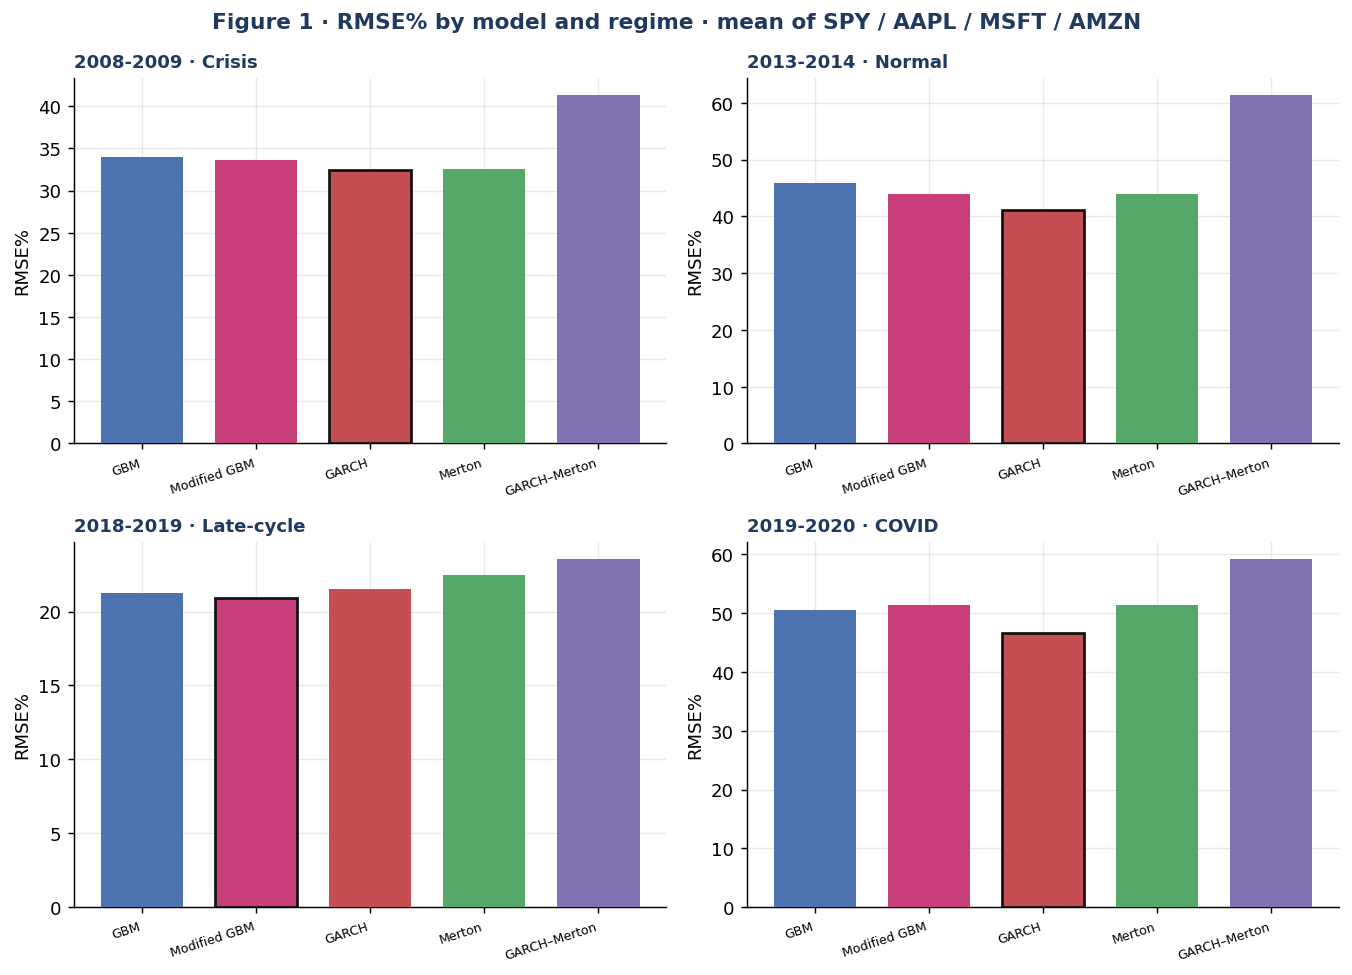

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


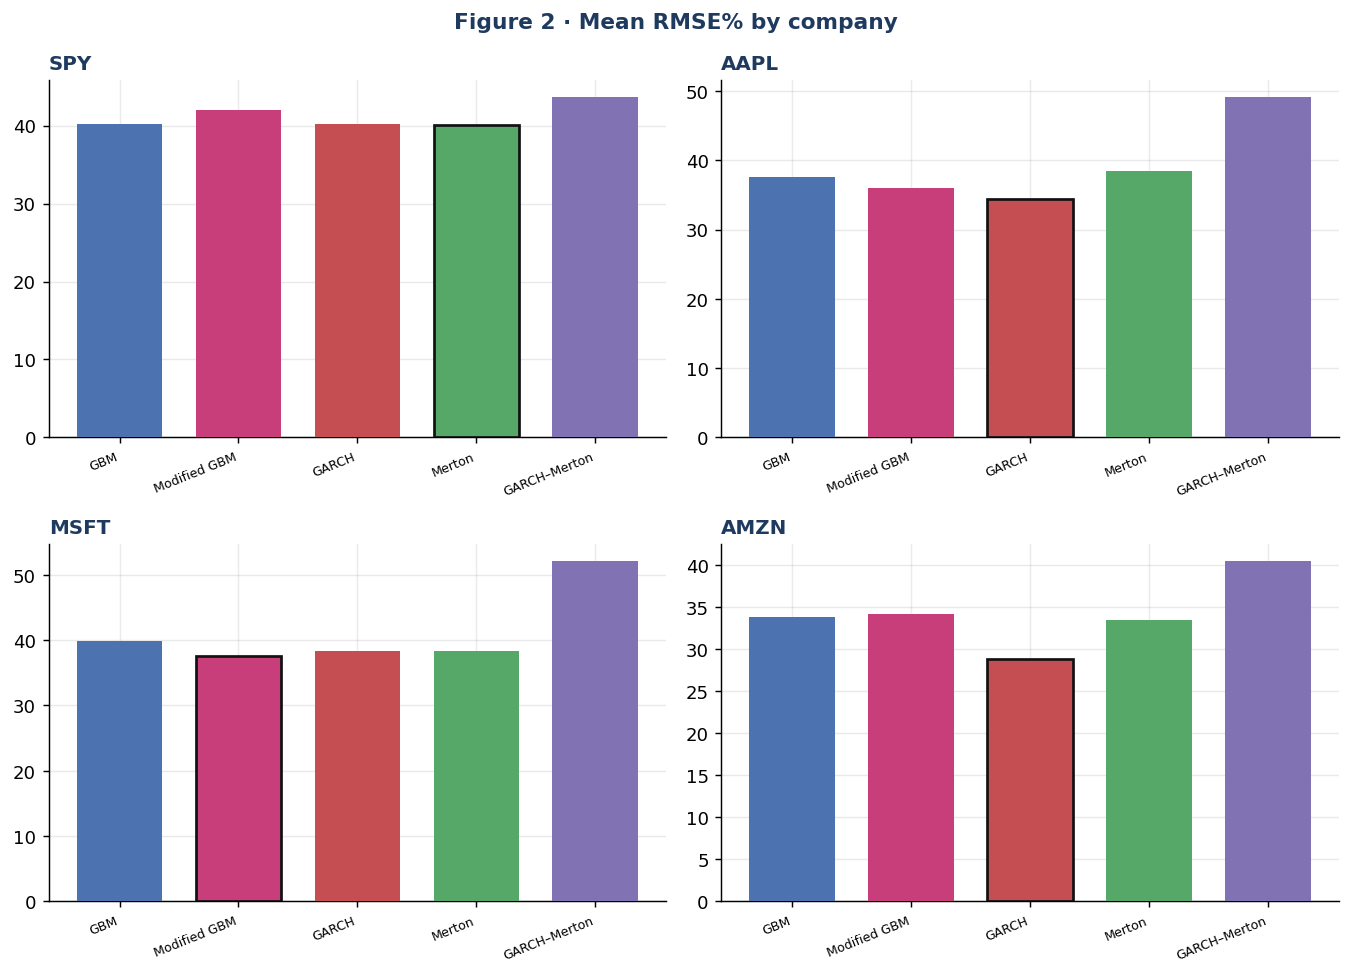

In [1]:
pass

### Figure 3 — Rank heatmap


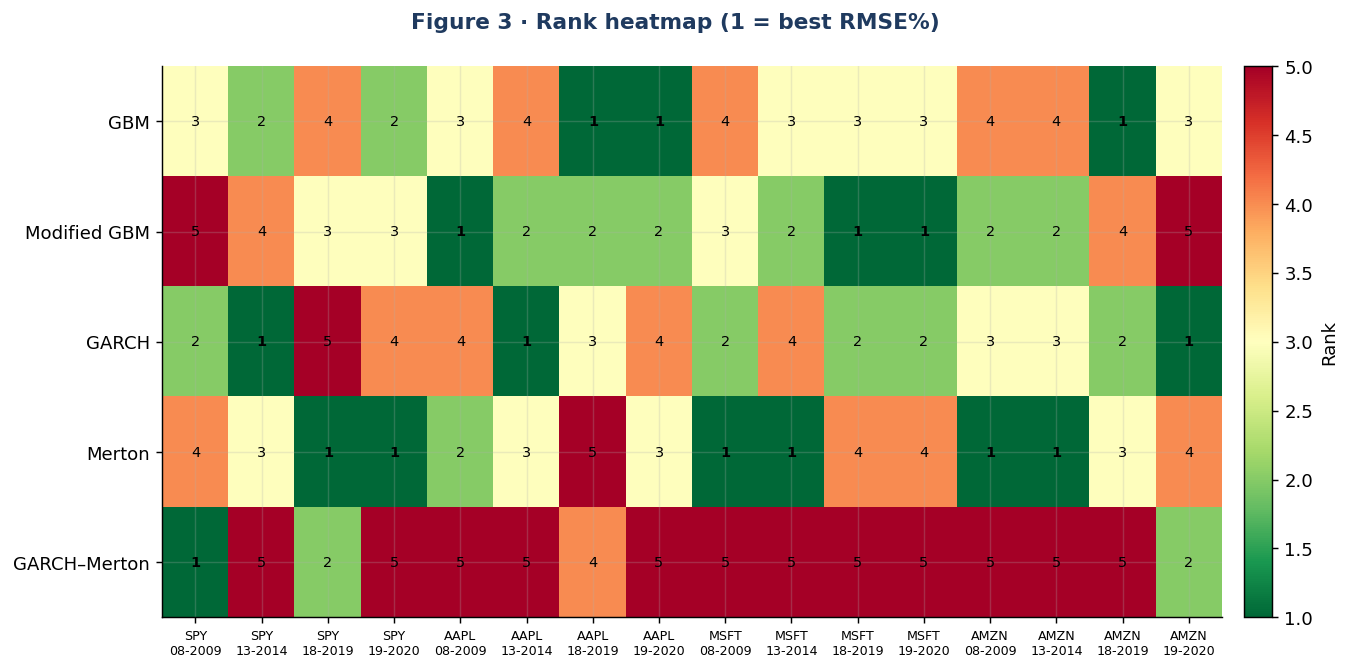

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, GARCH is the best overall model (mean RMSE% = 35.43; 3 of 16 cells).

- Second overall is Modified GBM (mean RMSE% = 37.46; 3 cells).

- The ranking is not stable. Best-in-cell models across the 16 tables: GARCH, GARCH–Merton, GBM, Merton, Modified GBM.

- SPY: lowest mean RMSE% is Merton (40.07); wins 2 of 4 regimes.

- AAPL: lowest mean RMSE% is GARCH (34.42); wins 1 of 4 regimes.

- MSFT: lowest mean RMSE% is Modified GBM (37.63); wins 2 of 4 regimes.

- AMZN: lowest mean RMSE% is GARCH (28.87); wins 1 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is GARCH (32.44).

- 2013-2014 (Normal): best mean RMSE% is GARCH (41.17).

- 2018-2019 (Late-cycle): best mean RMSE% is Modified GBM (20.89).

- 2019-2020 (COVID): best mean RMSE% is GARCH (46.57).

- No-jump models as a group have lower mean RMSE% (36.93) than the jump models in this report (41.98).

- For the overall winner (GARCH), crisis RMSE% is 32.44 vs 41.17 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year fixed calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

This grouped report is assembled from the frozen 10,000-path cells. No new calibration or LSM.

```python
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
groups.write_group('return_based')
```

The original six-model files `V3_1p5y_monthly_empirical_study.pdf` / `.ipynb` are not rewritten.
Partial results remain in `V4-Models_result/results/empirical_study_1p5y_fixed_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json`.
